# Aero Solver Validation Notebook

> Goal: validate and compare these implementations on identical airfoils/conditions:
- `numfoil.aero.xfoil.xfoil.py`
- `numfoil.aero.xfoil.xfoil_wrapper.py`
- `numfoil.aero.neuralfoil.neuralfoil_wrapper.py`
- `GADes.aero.neuralfoil_module.py` (`NeuralFoilTorch`)
- vanilla `neuralfoil` package (AeroSandbox ecosystem)

This notebook:
1. Builds a set of arbitrary airfoils using numfoil airfoil classes.
2. Evaluates each solver across ranges of alpha and Reynolds number.
3. Compares CL/CD/CM curves, runtime, and error tables.
4. Benchmarks vectorization vs looped evaluation.

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for parent in [start, *start.parents]:
        if (parent / "numfoil").exists() and (parent / "GADes").exists():
            return parent
    raise RuntimeError("Could not locate workspace root containing numfoil/ and GADes/")

REPO_ROOT = find_repo_root()
for extra_path in [
    REPO_ROOT / "numfoil" / "src",
    REPO_ROOT / "GADes" / "src",
    REPO_ROOT / "NeuralFoil",
]:
    extra_path_str = str(extra_path)
    if extra_path_str not in sys.path:
        sys.path.insert(0, extra_path_str)

print(f"Repo root: {REPO_ROOT}")

from numfoil.geometry.airfoil import NACA4Airfoil, KulfanAirfoil

availability = {}
load_errors = {}

try:
    from numfoil.aero.xfoil.xfoil import XFoil
    availability["xfoil.py"] = True
except Exception as exc:
    availability["xfoil.py"] = False
    load_errors["xfoil.py"] = repr(exc)

try:
    from numfoil.aero.neuralfoil.neuralfoil_wrapper import NeuralFoil as NumfoilNeuralFoil
    availability["neuralfoil_wrapper.py"] = True
except Exception as exc:
    availability["neuralfoil_wrapper.py"] = False
    load_errors["neuralfoil_wrapper.py"] = repr(exc)

try:
    from numfoil.aero.xfoil import xfoil_wrapper as xfoil_wrapper_legacy
    availability["xfoil_wrapper.py"] = True
except Exception as exc:
    availability["xfoil_wrapper.py"] = False
    load_errors["xfoil_wrapper.py"] = repr(exc)

try:
    import torch
    from GADes.aero.neuralfoil_module import NeuralFoilTorch
    availability["neuralfoil_module.py (GADes)"] = True
except Exception as exc:
    torch = None
    availability["neuralfoil_module.py (GADes)"] = False
    load_errors["neuralfoil_module.py (GADes)"] = repr(exc)

try:
    import neuralfoil as nf_vanilla
    availability["neuralfoil (vanilla asb)"] = True
except Exception as exc:
    nf_vanilla = None
    availability["neuralfoil (vanilla asb)"] = False
    load_errors["neuralfoil (vanilla asb)"] = repr(exc)

availability_df = pd.DataFrame(
    [
        {
            "solver": solver_name,
            "available": bool(is_available),
            "detail": "OK" if is_available else load_errors.get(solver_name, "unknown error"),
        }
        for solver_name, is_available in availability.items()
    ]
).sort_values("solver")

display(availability_df)

Repo root: c:\GitRepos\AAP


,solver,available,detail
4,neuralfoil (vanilla asb),True,OK
3,neuralfoil_module.py (GADes),True,OK
1,neuralfoil_wrapper.py,True,OK
0,xfoil.py,True,OK
2,xfoil_wrapper.py,True,OK


In [2]:
# ---- XFOIL hang prevention / diagnostics ----
XFOIL_TIMEOUT_SECONDS = 90.0
XFOIL_DEBUG_DIR = REPO_ROOT / "numfoil" / "src" / "numfoil" / "aero" / "xfoil" / "debug_logs"
XFOIL_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

os.environ["NUMFOIL_XFOIL_TIMEOUT_SECONDS"] = str(XFOIL_TIMEOUT_SECONDS)
os.environ["NUMFOIL_XFOIL_DEBUG_DIR"] = str(XFOIL_DEBUG_DIR)

print(
    "Configured XFOIL timeout: "
    f"{os.environ['NUMFOIL_XFOIL_TIMEOUT_SECONDS']} s "
    "(set NUMFOIL_XFOIL_TIMEOUT_SECONDS=0 to disable)."
)
print(f"XFOIL debug logs directory: {XFOIL_DEBUG_DIR}")
print("Each run writes <prefix>.stdin.txt/.stdout.txt/.stderr.txt/.meta.txt")

def show_recent_xfoil_debug_logs(limit=5):
    """List most recent XFOIL debug log prefixes for quick inspection."""
    meta_files = sorted(
        XFOIL_DEBUG_DIR.glob("*.meta.txt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )[:limit]
    if not meta_files:
        print("No XFOIL debug artifacts found yet.")
        return []
    print("Most recent XFOIL debug prefixes:")
    for meta in meta_files:
        prefix = str(meta).removesuffix(".meta.txt")
        print(f"  - {prefix}.*")
    return meta_files

def xfoil_smoke_test_once(airfoil, alpha=2.0, reynolds=5e5):
    """Run a single XFOIL operating point to verify subprocess responsiveness."""
    if not availability.get("xfoil.py", False):
        print("xfoil.py not available.")
        return
    solver = XFoil(iter=50)
    t0 = time.perf_counter()
    try:
        res = solver.analyze(
            airfoil=airfoil,
            alphas=np.asarray([float(alpha)]),
            reynolds=np.asarray([float(reynolds)]),
        )
        dt = time.perf_counter() - t0
        polar_df = res.polar.to_dataframe()
        print(f"xfoil.py smoke test OK in {dt:.3f}s, rows={len(polar_df)}")
    except Exception as exc:
        dt = time.perf_counter() - t0
        print(f"xfoil.py smoke test FAILED after {dt:.3f}s: {exc}")
        show_recent_xfoil_debug_logs(limit=3)

# Uncomment to run before the full benchmark:
# xfoil_smoke_test_once(next(iter(airfoil_cases.values())))

Configured XFOIL timeout: 90.0 s (set NUMFOIL_XFOIL_TIMEOUT_SECONDS=0 to disable).
XFOIL debug logs directory: c:\GitRepos\AAP\numfoil\src\numfoil\aero\xfoil\debug_logs
Each run writes <prefix>.stdin.txt/.stdout.txt/.stderr.txt/.meta.txt


In [3]:
rng = np.random.default_rng(42)

# Evaluation grid used for the main comparison.
alphas = np.arange(-4.0, 18.0, 1.0)
reynolds = np.array([2e5, 5e5, 7e5, 1e6, 3e6, 6e6], dtype=float)

# alphas = np.linspace(-4.0, 10.0, 10)
# reynolds = np.array([2e5, 5e5, 1e6], dtype=float)

# Base arbitrary shapes via a numfoil analytic class, then converted to Kulfan.
naca_codes = ["0012", "2412", "2422", "4415", "4812", "4822", "6409", "6412", "6422"]
# naca_codes = ["0012", "2412", "4415", "6409", "6412"]

base_naca_airfoils = [NACA4Airfoil(code) for code in naca_codes]

airfoil_cases: dict[str, KulfanAirfoil] = {}
for base_foil in base_naca_airfoils:
    kulfan_foil = KulfanAirfoil.from_coordinate_array(
        base_foil.points,
        n_coefficients=8,
        name=f"KF_{base_foil.name}",
        description=f"Kulfan fit of {base_foil.name}",
    )
    airfoil_cases[kulfan_foil.name] = kulfan_foil

# Add a couple of perturbed Kulfan variants to make the test set less canonical.
seed_foil = airfoil_cases["KF_NACA2412"]
for idx in range(2):
    created = False
    for _ in range(30):
        params = seed_foil.parameters.copy()
        params[:8] += rng.normal(0.0, 0.010, size=8)
        params[8:16] += rng.normal(0.0, 0.010, size=8)
        params[16] += rng.normal(0.0, 0.004)
        params[17] = np.clip(params[17] + rng.normal(0.0, 0.001), 0.0, 0.01)

        candidate = KulfanAirfoil.from_tensor(
            params,
            name=f"KF_PERT_{idx+1}",
            description="Perturbed Kulfan variant",
        )
        if candidate._validate_thickness():
            airfoil_cases[candidate.name] = candidate
            created = True
            break
    if not created:
        print(f"Could not create a valid perturbed foil for index {idx+1}")


print(f"Airfoils: {list(airfoil_cases.keys())}")
print(f"Alpha grid ({len(alphas)}): {alphas}")
print(f"Re grid ({len(reynolds)}): {reynolds}")

Airfoils: ['KF_NACA0012', 'KF_NACA2412', 'KF_NACA2422', 'KF_NACA4415', 'KF_NACA4812', 'KF_NACA4822', 'KF_NACA6409', 'KF_NACA6412', 'KF_NACA6422', 'KF_PERT_1', 'KF_PERT_2']
Alpha grid (22): [-4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.
 14. 15. 16. 17.]
Re grid (6): [ 200000.  500000.  700000. 1000000. 3000000. 6000000.]


c:\GitRepos\AAP\numfoil\src\numfoil\geometry\airfoil.py:86: UserWarning: Upper surface x-coordinates are not strictly increasing. Interpolator may be inaccurate.
  warning(
c:\GitRepos\AAP\numfoil\src\numfoil\geometry\airfoil.py:114: UserWarning: Upper surface x-coordinates are not strictly increasing. Interpolator may be inaccurate.
  warning(


In [4]:
_solver_cache = {}

def _standardize_polar_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ["Re", "alpha", "CL", "CD", "CM"]:
        if col not in out.columns:
            out[col] = np.nan
    out = out[["Re", "alpha", "CL", "CD", "CM"]].copy()
    out["Re"] = out["Re"].astype(float)
    out["alpha"] = out["alpha"].astype(float)
    out["CL"] = out["CL"].astype(float)
    out["CD"] = out["CD"].astype(float)
    out["CM"] = out["CM"].astype(float)
    out = out.sort_values(["Re", "alpha"]).reset_index(drop=True)
    return out

def _write_selig_dat(points: np.ndarray, filepath: str) -> None:
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    with open(filepath, "w", encoding="utf-8") as handle:
        handle.write("airfoil\n")
        for x, y in pts:
            handle.write(f"{x:.8f} {y:.8f}\n")

def _kulfan_dict_from_airfoil(airfoil: KulfanAirfoil) -> dict[str, np.ndarray | float]:
    p = np.asarray(airfoil.parameters, dtype=float).reshape(-1)
    if p.size != 18:
        raise ValueError(f"Expected 18 Kulfan parameters, got {p.size}")
    return {
        "upper_weights": p[:8],
        "lower_weights": p[8:16],
        "leading_edge_weight": float(p[16]),
        "TE_thickness": float(p[17]),
    }

def _get_xfoil_solver() -> "XFoil":
    if "xfoil.py" not in _solver_cache:
        _solver_cache["xfoil.py"] = XFoil(iter=100)
    return _solver_cache["xfoil.py"]

def _get_numfoil_neuralfoil_solver() -> "NumfoilNeuralFoil":
    if "neuralfoil_wrapper.py" not in _solver_cache:
        _solver_cache["neuralfoil_wrapper.py"] = NumfoilNeuralFoil(model_size="xxxlarge")
    return _solver_cache["neuralfoil_wrapper.py"]

def _get_gades_solver() -> "NeuralFoilTorch":
    if "neuralfoil_module.py (GADes)" not in _solver_cache:
        _solver_cache["neuralfoil_module.py (GADes)"] = NeuralFoilTorch(model_size="xxxlarge")
    return _solver_cache["neuralfoil_module.py (GADes)"]

def run_xfoil_new(
    airfoil: KulfanAirfoil,
    alphas: np.ndarray,
    reynolds: np.ndarray,
    **kwargs,
 ) -> tuple[pd.DataFrame, float]:
    solver = _get_xfoil_solver()
    t0 = time.perf_counter()
    result = solver.analyze(
        airfoil=airfoil,
        alphas=np.asarray(alphas, dtype=float),
        reynolds=np.asarray(reynolds, dtype=float),
    )
    elapsed = time.perf_counter() - t0
    df = _standardize_polar_df(result.polar.to_dataframe())
    return df, elapsed

def run_xfoil_wrapper_legacy(
    airfoil: KulfanAirfoil,
    alphas: np.ndarray,
    reynolds: np.ndarray,
    **kwargs,
 ) -> tuple[pd.DataFrame, float]:
    if not availability.get("xfoil_wrapper.py", False):
        raise RuntimeError("xfoil_wrapper.py is not available in this environment")

    dat_name = f"_tmp_{airfoil.name.replace(' ', '_')}.dat"
    dat_path = str(Path.cwd() / dat_name)
    _write_selig_dat(airfoil.points, dat_path)

    def col_as_float(raw: dict, names: tuple[str, ...], n: int) -> np.ndarray:
        for name in names:
            if name in raw:
                return np.asarray(raw[name], dtype=float)
        return np.full(n, np.nan, dtype=float)

    t0 = time.perf_counter()
    frames = []
    try:
        for re_value in np.asarray(reynolds, dtype=float):
            raw = xfoil_wrapper_legacy.find_coefficients(
                dat_name,
                alpha=[float(a) for a in np.asarray(alphas, dtype=float)],
                Reynolds=float(re_value),
                iteration=100,
                NACA=False,
                delete=True,
                PANE=False,
                GDES=False,
            )

            n = len(raw.get("alpha", [])) if isinstance(raw, dict) else 0
            if n == 0:
                continue

            frame = pd.DataFrame(
                {
                    "alpha": np.asarray(raw["alpha"], dtype=float),
                    "CL": col_as_float(raw, ("CL",), n),
                    "CD": col_as_float(raw, ("CD",), n),
                    "CM": col_as_float(raw, ("CM",), n),
                    "Re": float(re_value),
                }
            )
            frames.append(frame)
    finally:
        if os.path.exists(dat_path):
            os.remove(dat_path)
        for pattern in [
            f"Polar_{dat_name}*",
            f"Cp_{dat_name}*",
            f"Dump_{dat_name}*",
            f"Alfa_L_0_{dat_name}*",
        ]:
            for leftover in Path.cwd().glob(pattern):
                try:
                    leftover.unlink()
                except OSError:
                    pass

    elapsed = time.perf_counter() - t0
    if not frames:
        empty = pd.DataFrame(columns=["Re", "alpha", "CL", "CD", "CM"])
        return empty, elapsed

    df = _standardize_polar_df(pd.concat(frames, ignore_index=True))
    return df, elapsed

def run_neuralfoil_numfoil(
    airfoil: KulfanAirfoil,
    alphas: np.ndarray,
    reynolds: np.ndarray,
    *,
    batch_size: int | float = np.inf,
    **kwargs,
 ) -> tuple[pd.DataFrame, float]:
    solver = _get_numfoil_neuralfoil_solver()
    t0 = time.perf_counter()
    result = solver.analyze(
        airfoil=airfoil,
        alphas=np.asarray(alphas, dtype=float),
        reynolds=np.asarray(reynolds, dtype=float),
        batch_size=batch_size,
    )
    elapsed = time.perf_counter() - t0
    df = _standardize_polar_df(result.polar.to_dataframe())
    return df, elapsed

def run_gades_neuralfoil_module(
    airfoil: KulfanAirfoil,
    alphas: np.ndarray,
    reynolds: np.ndarray,
    **kwargs,
 ) -> tuple[pd.DataFrame, float]:
    if torch is None:
        raise RuntimeError("PyTorch/GADes is not available")

    solver = _get_gades_solver()
    params = np.asarray(airfoil.parameters, dtype=np.float32).reshape(1, -1)
    kulfan_batch = torch.as_tensor(params, dtype=torch.float32)
    alpha_t = torch.as_tensor(np.asarray(alphas, dtype=np.float32))
    re_t = torch.as_tensor(np.asarray(reynolds, dtype=np.float32))

    t0 = time.perf_counter()
    raw = solver.batch_eval(kulfan_batch, alpha=alpha_t, Re=re_t)
    elapsed = time.perf_counter() - t0

    cl = raw["CL"].detach().cpu().numpy()[0]
    cd = raw["CD"].detach().cpu().numpy()[0]
    cm = raw["CM"].detach().cpu().numpy()[0]

    rr, aa = np.meshgrid(np.asarray(reynolds, dtype=float), np.asarray(alphas, dtype=float), indexing="ij")
    df = pd.DataFrame(
        {
            "Re": rr.reshape(-1),
            "alpha": aa.reshape(-1),
            "CL": cl.reshape(-1),
            "CD": cd.reshape(-1),
            "CM": cm.reshape(-1),
        }
    )
    return _standardize_polar_df(df), elapsed

def run_vanilla_neuralfoil(
    airfoil: KulfanAirfoil,
    alphas: np.ndarray,
    reynolds: np.ndarray,
    *,
    model_size: str = "xxxlarge",
    **kwargs,
 ) -> tuple[pd.DataFrame, float]:
    if nf_vanilla is None:
        raise RuntimeError("vanilla neuralfoil package is not available")

    kulfan = _kulfan_dict_from_airfoil(airfoil)
    rr, aa = np.meshgrid(np.asarray(reynolds, dtype=float), np.asarray(alphas, dtype=float), indexing="ij")
    re_flat = rr.reshape(-1)
    alpha_flat = aa.reshape(-1)

    t0 = time.perf_counter()
    raw = nf_vanilla.get_aero_from_kulfan_parameters(
        kulfan_parameters=kulfan,
        alpha=alpha_flat,
        Re=re_flat,
        model_size=model_size,
    )
    elapsed = time.perf_counter() - t0

    df = pd.DataFrame(
        {
            "Re": re_flat,
            "alpha": alpha_flat,
            "CL": np.asarray(raw["CL"], dtype=float).reshape(-1),
            "CD": np.asarray(raw["CD"], dtype=float).reshape(-1),
            "CM": np.asarray(raw["CM"], dtype=float).reshape(-1),
        }
    )
    return _standardize_polar_df(df), elapsed

solver_runners = {}
if availability.get("xfoil.py", False):
    solver_runners["xfoil.py"] = run_xfoil_new
if availability.get("xfoil_wrapper.py", False):
    solver_runners["xfoil_wrapper.py"] = run_xfoil_wrapper_legacy
if availability.get("neuralfoil_wrapper.py", False):
    solver_runners["neuralfoil_wrapper.py"] = run_neuralfoil_numfoil
if availability.get("neuralfoil_module.py (GADes)", False):
    solver_runners["neuralfoil_module.py (GADes)"] = run_gades_neuralfoil_module
if availability.get("neuralfoil (vanilla asb)", False):
    solver_runners["neuralfoil (vanilla asb)"] = run_vanilla_neuralfoil

print("Configured solver runners:", list(solver_runners.keys()))

Configured solver runners: ['xfoil.py', 'xfoil_wrapper.py', 'neuralfoil_wrapper.py', 'neuralfoil_module.py (GADes)', 'neuralfoil (vanilla asb)']


In [5]:
benchmark_frames = []
runtime_records = []

for airfoil_name, airfoil in airfoil_cases.items():
    print(f"\n=== Airfoil: {airfoil_name} ===")
    for solver_name, runner in solver_runners.items():
        print(f"Running solver: {solver_name}...", end="\n", flush=True)
        try:
            df_solver, elapsed = runner(airfoil=airfoil, alphas=alphas, reynolds=reynolds)
            df_solver = _standardize_polar_df(df_solver)
            if df_solver.empty:
                status = "empty"
                print(f"[{solver_name}] no data returned")
            else:
                status = "ok"
                df_solver["solver"] = solver_name
                df_solver["airfoil"] = airfoil_name
                benchmark_frames.append(df_solver)
                print(f"[{solver_name}] {len(df_solver)} points in {elapsed:.3f}s")

            runtime_records.append(
                {
                    "solver": solver_name,
                    "airfoil": airfoil_name,
                    "seconds": float(elapsed),
                    "n_cases": int(len(df_solver)),
                    "status": status,
                }
            )
        except Exception as exc:
            runtime_records.append(
                {
                    "solver": solver_name,
                    "airfoil": airfoil_name,
                    "seconds": np.nan,
                    "n_cases": 0,
                    "status": f"failed: {exc}",
                }
            )
            print(f"[{solver_name}] FAILED: {exc}")

benchmark_df = (
    pd.concat(benchmark_frames, ignore_index=True)
    if benchmark_frames
    else pd.DataFrame(columns=["solver", "airfoil", "Re", "alpha", "CL", "CD", "CM"])
)

runtime_df = pd.DataFrame(runtime_records)

display(runtime_df.sort_values(["airfoil", "solver"]).reset_index(drop=True))
print(f"Total benchmark rows: {len(benchmark_df)}")


=== Airfoil: KF_NACA0012 ===
Running solver: xfoil.py...
XFOIL: 6 sessions, 22 alpha each
  [1/6] Re = 2.00e+05 ... done  (4.8s elapsed)
  [2/6] Re = 5.00e+05 ... done  (7.5s elapsed)
  [3/6] Re = 7.00e+05 ... done  (10.7s elapsed)
  [4/6] Re = 1.00e+06 ... done  (15.3s elapsed)
  [5/6] Re = 3.00e+06 ... done  (18.4s elapsed)
  [6/6] Re = 6.00e+06 ... done  (22.9s elapsed)
[xfoil.py] 125 points in 22.929s
Running solver: xfoil_wrapper.py...
[xfoil_wrapper.py] 128 points in 16.708s
Running solver: neuralfoil_wrapper.py...
NeuralFoil: batched inference (6 Re x 22 alpha = 132 cases), chunk=132
[neuralfoil_wrapper.py] 132 points in 0.087s
Running solver: neuralfoil_module.py (GADes)...
[neuralfoil_module.py (GADes)] 132 points in 0.105s
Running solver: neuralfoil (vanilla asb)...
[neuralfoil (vanilla asb)] 132 points in 0.038s

=== Airfoil: KF_NACA2412 ===
Running solver: xfoil.py...
XFOIL: 6 sessions, 22 alpha each
  [1/6] Re = 2.00e+05 ... done  (4.0s elapsed)
  [2/6] Re = 5.00e+05 ... 

,solver,airfoil,seconds,n_cases,status
0,neuralfoil (vanilla asb),KF_NACA0012,0.038331,132,ok
1,neuralfoil_module.py (GADes),KF_NACA0012,0.105440,132,ok
2,neuralfoil_wrapper.py,KF_NACA0012,0.087443,132,ok
3,xfoil.py,KF_NACA0012,22.928986,125,ok
4,xfoil_wrapper.py,KF_NACA0012,16.708256,128,ok
5,neuralfoil (vanilla asb),KF_NACA2412,0.031043,132,ok
6,neuralfoil_module.py (GADes),KF_NACA2412,0.008700,132,ok
7,neuralfoil_wrapper.py,KF_NACA2412,0.064039,132,ok
8,xfoil.py,KF_NACA2412,18.134828,132,ok
9,xfoil_wrapper.py,KF_NACA2412,16.125296,131,ok


Total benchmark rows: 7153


In [6]:
availability_report = pd.DataFrame(
    [
        {
            "solver": s,
            "available": availability.get(s, False),
            "detail": "OK" if availability.get(s, False) else load_errors.get(s, "n/a"),
        }
        for s in [
            "xfoil.py",
            "xfoil_wrapper.py",
            "neuralfoil_wrapper.py",
            "neuralfoil_module.py (GADes)",
            "neuralfoil (vanilla asb)",
        ]
    ]
)

print("Solver availability report")
display(availability_report)

if not runtime_df.empty:
    successful = runtime_df[runtime_df["status"] == "ok"].copy()
    if not successful.empty:
        successful["sec_per_case"] = successful["seconds"] / successful["n_cases"].replace(0, np.nan)
        runtime_summary = successful.groupby("solver", as_index=False).agg(
            runs=("solver", "size"),
            total_seconds=("seconds", "sum"),
            mean_seconds=("seconds", "mean"),
            mean_sec_per_case=("sec_per_case", "mean"),
            total_cases=("n_cases", "sum"),
        ).sort_values("mean_seconds")
        print("\nRuntime summary")
        display(runtime_summary)
    else:
        print("No successful solver runs were recorded.")

Solver availability report


,solver,available,detail
0,xfoil.py,True,OK
1,xfoil_wrapper.py,True,OK
2,neuralfoil_wrapper.py,True,OK
3,neuralfoil_module.py (GADes),True,OK
4,neuralfoil (vanilla asb),True,OK



Runtime summary


,solver,runs,total_seconds,mean_seconds,mean_sec_per_case,total_cases
1,neuralfoil_module.py (GADes),11,0.302144,0.027468,0.000208,1452
0,neuralfoil (vanilla asb),11,0.394340,0.035849,0.000272,1452
2,neuralfoil_wrapper.py,11,0.791155,0.071923,0.000545,1452
4,xfoil_wrapper.py,11,187.982525,17.089320,0.135792,1394
3,xfoil.py,11,209.483500,19.043955,0.149739,1403


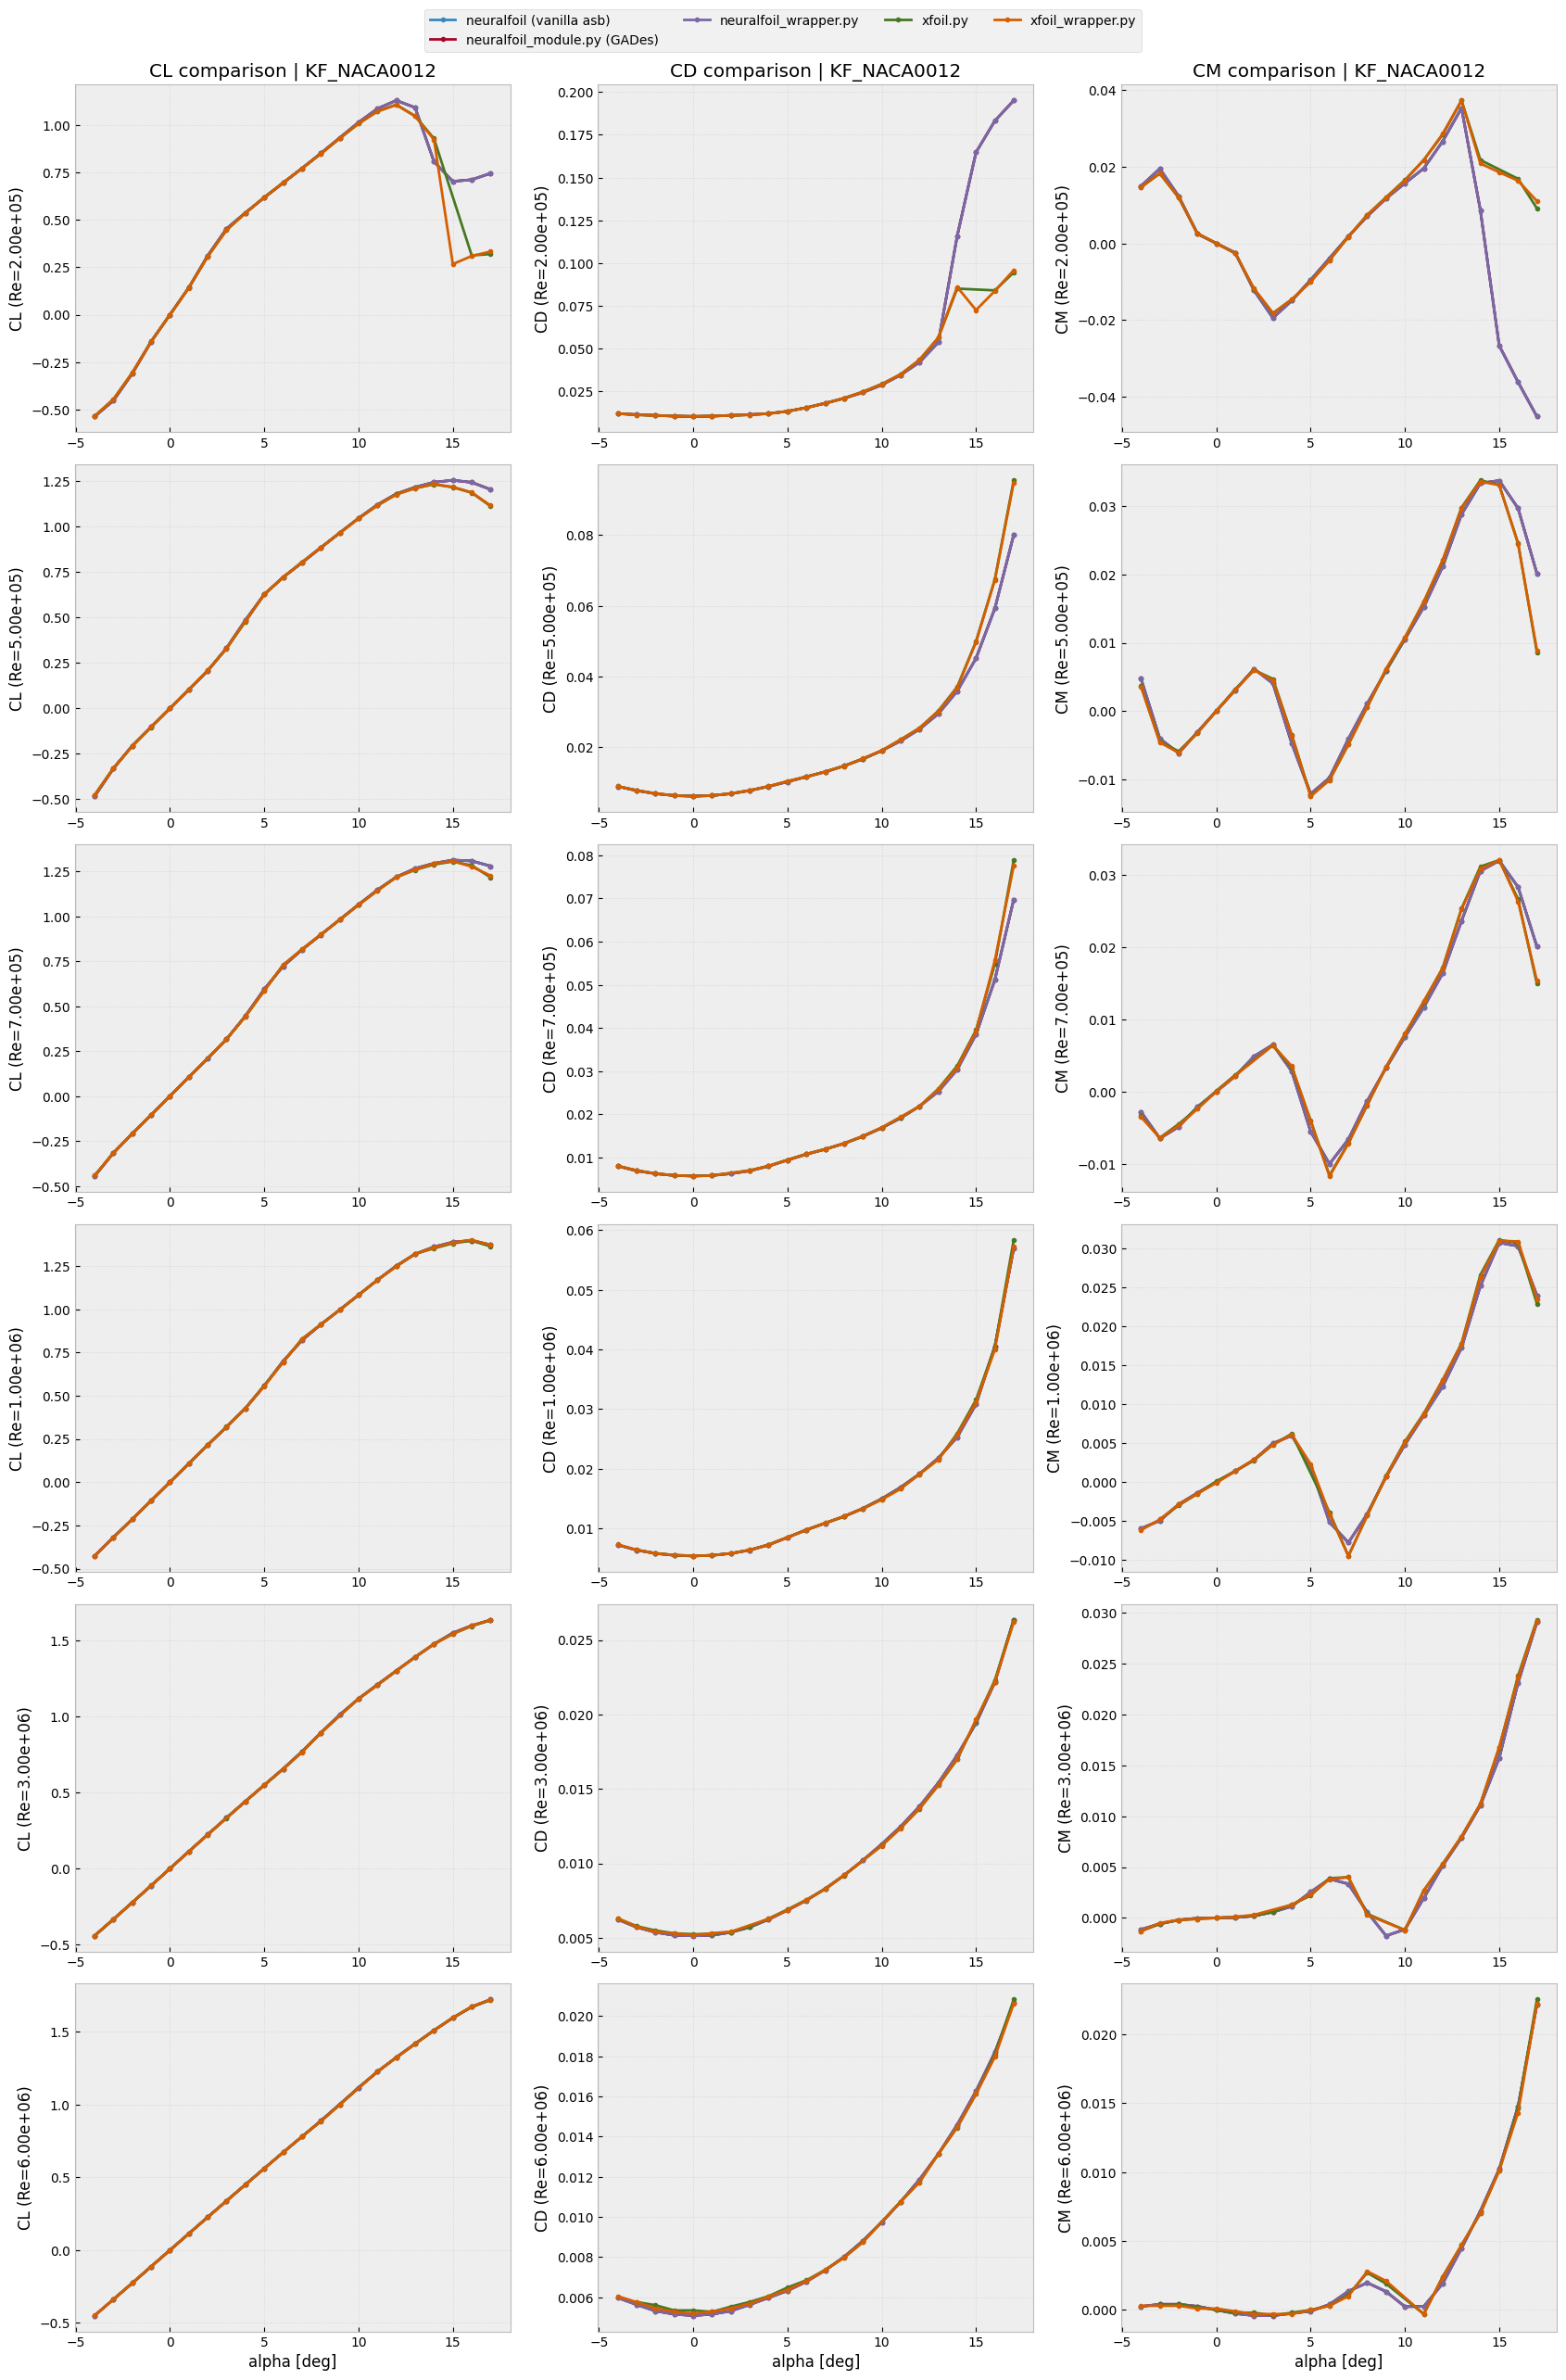

In [7]:
if benchmark_df.empty:
    raise RuntimeError("No benchmark data available. Check solver availability and run cell 5 first.")

plot_airfoil = sorted(benchmark_df["airfoil"].unique())[0]
plot_df = benchmark_df[benchmark_df["airfoil"] == plot_airfoil].copy()
plot_re_values = sorted(plot_df["Re"].unique())

fig, axes = plt.subplots(
    nrows=len(plot_re_values),
    ncols=3,
    figsize=(17, 4.2 * len(plot_re_values)),
    squeeze=False,
    sharex=False,
    sharey=False,
)

for row_idx, re_value in enumerate(plot_re_values):
    sub = plot_df[plot_df["Re"] == re_value].copy()
    for solver_name, group in sub.groupby("solver"):
        g = group.sort_values("alpha")
        axes[row_idx, 0].plot(g["alpha"], g["CL"], marker="o", markersize=3, label=solver_name)
        axes[row_idx, 1].plot(g["alpha"], g["CD"], marker="o", markersize=3, label=solver_name)
        axes[row_idx, 2].plot(g["alpha"], g["CM"], marker="o", markersize=3, label=solver_name)

    axes[row_idx, 0].set_ylabel(f"CL (Re={re_value:.2e})")
    axes[row_idx, 1].set_ylabel(f"CD (Re={re_value:.2e})")
    axes[row_idx, 2].set_ylabel(f"CM (Re={re_value:.2e})")

    axes[row_idx, 0].grid(True, alpha=0.3)
    axes[row_idx, 1].grid(True, alpha=0.3)
    axes[row_idx, 2].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("alpha [deg]")
axes[-1, 1].set_xlabel("alpha [deg]")
axes[-1, 2].set_xlabel("alpha [deg]")
axes[0, 0].set_title(f"CL comparison | {plot_airfoil}")
axes[0, 1].set_title(f"CD comparison | {plot_airfoil}")
axes[0, 2].set_title(f"CM comparison | {plot_airfoil}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

In [8]:
if benchmark_df.empty:
    raise RuntimeError("No benchmark data available. Run the benchmark cell first.")

candidate_reference_order = ["xfoil.py", "neuralfoil (vanilla asb)", "neuralfoil_wrapper.py"]
reference_solver = next((s for s in candidate_reference_order if s in set(benchmark_df["solver"])), None)
if reference_solver is None:
    raise RuntimeError("No suitable reference solver found in benchmark data.")

print(f"Reference solver for error metrics: {reference_solver}")

keys = ["airfoil", "Re", "alpha"]
reference = benchmark_df[benchmark_df["solver"] == reference_solver][keys + ["CL", "CD", "CM"]].copy()
reference = reference.rename(columns={"CL": "CL_ref", "CD": "CD_ref", "CM": "CM_ref"})

compare = benchmark_df[benchmark_df["solver"] != reference_solver].merge(reference, on=keys, how="inner")

if compare.empty:
    print("No overlapping points to compare against the reference.")
else:
    eps = 1e-12
    for coeff in ["CL", "CD", "CM"]:
        compare[f"abs_err_{coeff}"] = np.abs(compare[coeff] - compare[f"{coeff}_ref"])
        compare[f"rel_err_{coeff}"] = compare[f"abs_err_{coeff}"] / (np.abs(compare[f"{coeff}_ref"]) + eps)

    error_summary = compare.groupby("solver", as_index=False).agg(
        points=("solver", "size"),
        mae_CL=("abs_err_CL", "mean"),
        mae_CD=("abs_err_CD", "mean"),
        mae_CM=("abs_err_CM", "mean"),
        mape_CL=("rel_err_CL", "mean"),
        mape_CD=("rel_err_CD", "mean"),
        mape_CM=("rel_err_CM", "mean"),
        max_abs_CL=("abs_err_CL", "max"),
        max_abs_CD=("abs_err_CD", "max"),
        max_abs_CM=("abs_err_CM", "max"),
    ).sort_values(["mae_CL", "mae_CD", "mae_CM"])

    error_by_airfoil = compare.groupby(["solver", "airfoil"], as_index=False).agg(
        points=("solver", "size"),
        mae_CL=("abs_err_CL", "mean"),
        mae_CD=("abs_err_CD", "mean"),
        mae_CM=("abs_err_CM", "mean"),
    ).sort_values(["solver", "airfoil"])

    print("Solver-level error summary")
    display(error_summary)
    print("Per-airfoil error summary")
    display(error_by_airfoil)

Reference solver for error metrics: xfoil.py
Solver-level error summary


,solver,points,mae_CL,mae_CD,mae_CM,mape_CL,mape_CD,mape_CM,max_abs_CL,max_abs_CD,max_abs_CM
3,xfoil_wrapper.py,1366,0.001025,0.000084,0.000160,439238.658923,0.003739,73206.451542,0.037000,0.005970,0.006100
1,neuralfoil_module.py (GADes),1403,0.009952,0.000885,0.001472,0.021529,0.027476,62633.791578,0.426227,0.100694,0.054189
0,neuralfoil (vanilla asb),1403,0.009952,0.000885,0.001472,0.021529,0.027476,62694.835789,0.426226,0.100693,0.054189
2,neuralfoil_wrapper.py,1403,0.009952,0.000885,0.001472,0.021529,0.027476,62694.835789,0.426226,0.100693,0.054189


Per-airfoil error summary


,solver,airfoil,points,mae_CL,mae_CD,mae_CM
0,neuralfoil (vanilla asb),KF_NACA0012,125,0.012471,0.002343,0.001564
1,neuralfoil (vanilla asb),KF_NACA2412,132,0.004243,0.000434,0.000592
2,neuralfoil (vanilla asb),KF_NACA2422,126,0.003718,0.000189,0.000635
3,neuralfoil (vanilla asb),KF_NACA4415,131,0.003433,0.000176,0.000424
4,neuralfoil (vanilla asb),KF_NACA4812,126,0.009813,0.000758,0.001566
5,neuralfoil (vanilla asb),KF_NACA4822,126,0.010120,0.000583,0.001669
6,neuralfoil (vanilla asb),KF_NACA6409,123,0.006461,0.000574,0.000874
7,neuralfoil (vanilla asb),KF_NACA6412,128,0.002893,0.000131,0.000402
8,neuralfoil (vanilla asb),KF_NACA6422,127,0.047589,0.003678,0.007475
9,neuralfoil (vanilla asb),KF_PERT_1,127,0.005197,0.000559,0.000612


In [9]:
# Vectorization capability benchmark
vector_airfoil = next(iter(airfoil_cases.values()))
alpha_vec = np.linspace(-4.0, 10.0, 8)
re_vec = np.array([3e5, 7e5, 1.5e6], dtype=float)
n_combo_cases = int(len(alpha_vec) * len(re_vec))

def _timeit(fn) -> float:
    t0 = time.perf_counter()
    fn()
    return time.perf_counter() - t0

def _with_temp_dat(airfoil: KulfanAirfoil, fn):
    dat_name = f"_tmp_vec_{airfoil.name.replace(' ', '_')}.dat"
    dat_path = str(Path.cwd() / dat_name)
    _write_selig_dat(airfoil.points, dat_path)
    try:
        return fn(dat_name)
    finally:
        if os.path.exists(dat_path):
            os.remove(dat_path)
        for pattern in [
            f"Polar_{dat_name}*",
            f"Cp_{dat_name}*",
            f"Dump_{dat_name}*",
            f"Alfa_L_0_{dat_name}*",
        ]:
            for leftover in Path.cwd().glob(pattern):
                try:
                    leftover.unlink()
                except OSError:
                    pass

vectorization_records = []

def record_vectorization(solver_name: str, mode_note: str, loop_fn, vector_fn, n_cases: int):
    t_loop = _timeit(loop_fn)
    t_vector = _timeit(vector_fn)
    vectorization_records.append(
        {
            "solver": solver_name,
            "mode": mode_note,
            "n_cases": n_cases,
            "loop_seconds": t_loop,
            "vector_seconds": t_vector,
            "speedup_x": (t_loop / t_vector) if t_vector > 0 else np.nan,
        }
    )

if "xfoil.py" in solver_runners:
    xfoil_solver = _get_xfoil_solver()
    record_vectorization(
        "xfoil.py",
        "vectorized over alpha and Re (single analyze call)",
        lambda: [
            xfoil_solver.analyze(vector_airfoil, alphas=[float(a)], reynolds=[float(r)])
            for r in re_vec for a in alpha_vec
        ],
        lambda: xfoil_solver.analyze(vector_airfoil, alphas=alpha_vec, reynolds=re_vec),
        n_combo_cases,
    )

if "xfoil_wrapper.py" in solver_runners:
    record_vectorization(
        "xfoil_wrapper.py",
        "vectorized over alpha only (Re loop still explicit)",
        lambda: _with_temp_dat(
            vector_airfoil,
            lambda dat_name: [
                xfoil_wrapper_legacy.find_coefficients(
                    dat_name,
                    alpha=float(a),
                    Reynolds=float(r),
                    iteration=100,
                    NACA=False,
                    delete=True,
                    PANE=False,
                    GDES=False,
                )
                for r in re_vec for a in alpha_vec
            ],
        ),
        lambda: _with_temp_dat(
            vector_airfoil,
            lambda dat_name: [
                xfoil_wrapper_legacy.find_coefficients(
                    dat_name,
                    alpha=[float(a) for a in alpha_vec],
                    Reynolds=float(r),
                    iteration=100,
                    NACA=False,
                    delete=True,
                    PANE=False,
                    GDES=False,
                )
                for r in re_vec
            ],
        ),
        n_combo_cases,
    )

if "neuralfoil_wrapper.py" in solver_runners:
    nf_solver = _get_numfoil_neuralfoil_solver()
    record_vectorization(
        "neuralfoil_wrapper.py",
        "full Re x alpha grid (batch_size=np.inf)",
        lambda: [
            nf_solver.analyze(vector_airfoil, alphas=[float(a)], reynolds=[float(r)], batch_size=0)
            for r in re_vec for a in alpha_vec
        ],
        lambda: nf_solver.analyze(vector_airfoil, alphas=alpha_vec, reynolds=re_vec, batch_size=np.inf),
        n_combo_cases,
    )

if "neuralfoil_module.py (GADes)" in solver_runners:
    gades_solver = _get_gades_solver()
    params = torch.as_tensor(np.asarray(vector_airfoil.parameters, dtype=np.float32).reshape(1, -1), dtype=torch.float32)
    record_vectorization(
        "neuralfoil_module.py (GADes)",
        "full Re x alpha grid with batch_eval",
        lambda: [
            gades_solver.batch_eval(
                params,
                alpha=torch.as_tensor([float(a)], dtype=torch.float32),
                Re=torch.as_tensor([float(r)], dtype=torch.float32),
            )
            for r in re_vec for a in alpha_vec
        ],
        lambda: gades_solver.batch_eval(
            params,
            alpha=torch.as_tensor(alpha_vec.astype(np.float32)),
            Re=torch.as_tensor(re_vec.astype(np.float32)),
        ),
        n_combo_cases,
    )

if "neuralfoil (vanilla asb)" in solver_runners:
    kulfan = _kulfan_dict_from_airfoil(vector_airfoil)
    rr, aa = np.meshgrid(re_vec, alpha_vec, indexing="ij")
    re_flat = rr.reshape(-1)
    alpha_flat = aa.reshape(-1)
    record_vectorization(
        "neuralfoil (vanilla asb)",
        "flattened full grid call",
        lambda: [
            nf_vanilla.get_aero_from_kulfan_parameters(
                kulfan_parameters=kulfan,
                alpha=float(a),
                Re=float(r),
                model_size="xxxlarge",
            )
            for r in re_vec for a in alpha_vec
        ],
        lambda: nf_vanilla.get_aero_from_kulfan_parameters(
            kulfan_parameters=kulfan,
            alpha=alpha_flat,
            Re=re_flat,
            model_size="xxxlarge",
        ),
        n_combo_cases,
    )

vectorization_df = pd.DataFrame(vectorization_records)
display(vectorization_df.sort_values("speedup_x", ascending=False))

XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.5s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.4s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (1.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 3.00e+05 ... done  (0.2s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 7.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 7.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 7.00e+05 ... done  (0.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 7.00e+05 ... done  (1.3s elapsed)
XFOIL: 1 session, 1 alpha each
  [1/1] Re = 7.00e+05 ... done  (

,solver,mode,n_cases,loop_seconds,vector_seconds,speedup_x
4,neuralfoil (vanilla asb),flattened full grid call,24,0.243787,0.018750,13.002315
2,neuralfoil_wrapper.py,full Re x alpha grid (batch_size=np.inf),24,0.237176,0.018773,12.634169
3,neuralfoil_module.py (GADes),full Re x alpha grid with batch_eval,24,0.052860,0.009211,5.738907
0,xfoil.py,vectorized over alpha and Re (single analyze c...,24,9.289120,4.169256,2.228004
1,xfoil_wrapper.py,vectorized over alpha only (Re loop still expl...,24,7.562604,3.586142,2.108841


Vectorization capability matrix  (✓ = supported, — = not supported):


,alpha,Re,airfoils,notes
solver,,,,
xfoil.py,✓,✓,✓,accepts multi-airfoil analyze(); loops internally
xfoil_wrapper.py,✓,—,—,scalar Re per XFOIL session; alpha list only
neuralfoil_wrapper.py,✓,✓,✓,analyze() accepts multi-airfoil input and runs...
neuralfoil_module.py (GADes),✓,✓,✓,"batch_eval() accepts kulfan_batch shape [B, 18]"
neuralfoil (vanilla asb),✓,✓,✓,"Kulfan coefficients tiled as [8, N_total]"



Mega-batch grid: 11 airfoils x 3 Re x 8 alpha = 264 total cases

Timing multi-airfoil evaluations (NN solvers):
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: batched inference (3 Re x 8 alpha = 24 cases), chunk=24
NeuralFoil: mega-batch inference (11 foils x 3 Re x 8 alpha = 264 cases)
  neuralfoil_wrapper.py: seq=0.5024s  batch=0.2344s  (2.1x faster)

,solver,n_total_cases,sequential_s,batched_s,speedup_x,airfoil_batching
1,neuralfoil_module.py (GADes),264,0.1197,0.0202,5.92,✓
2,neuralfoil (vanilla asb),264,0.2015,0.1073,1.88,✓
0,neuralfoil_wrapper.py,264,0.5024,0.2344,2.14,✓



Validating fully vectorized single-call runs and Reynolds indexing:
NeuralFoil: mega-batch inference (11 foils x 3 Re x 8 alpha = 264 cases)


,solver,expected_cases,received_cases,single_call_ok,re_indexing_ok,cases_match,details
0,neuralfoil (vanilla asb),264,264,True,True,True,"coefficient-first kulfan tiling [8, N_total]"
1,neuralfoil_module.py (GADes),264,264,True,True,True,"CL shape=(11, 3, 8)"
2,neuralfoil_wrapper.py,264,264,True,True,True,airfoils=11


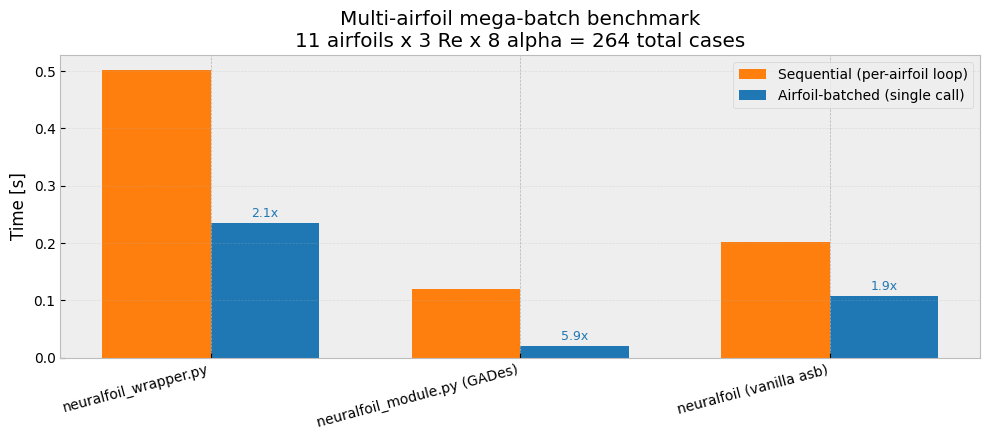

In [13]:
# Multi-airfoil ("mega-batch") vectorization benchmark
# -----------------------------------------------------------------------------
# Ensure the notebook kernel uses the latest local edits for numfoil modules.
import importlib
import numfoil.aero.aeroresults as _aeroresults_mod
import numfoil.aero.neuralfoil.neuralfoil_wrapper as _nfw_mod
import numfoil.aero.xfoil.xfoil as _xfoil_mod

importlib.reload(_aeroresults_mod)
importlib.reload(_nfw_mod)
importlib.reload(_xfoil_mod)

from numfoil.aero.neuralfoil.neuralfoil_wrapper import NeuralFoil as NumfoilNeuralFoil
from numfoil.aero.xfoil.xfoil import XFoil

_solver_cache.pop("neuralfoil_wrapper.py", None)
_solver_cache.pop("xfoil.py", None)

# The previous cell checks alpha x Re vectorization for ONE airfoil.
# This cell checks whether each solver can evaluate ALL airfoils x Re x alpha
# in one call, and validates output completeness + Reynolds indexing behavior.

# Capability matrix legend:
#   ✓  -> supported natively in one call
#   —  -> not supported
_cap_rows = [
    (
        "xfoil.py",
        "✓",
        "✓",
        "✓",
        "accepts multi-airfoil analyze(); loops internally",
    ),
    (
        "xfoil_wrapper.py",
        "✓",
        "—",
        "—",
        "scalar Re per XFOIL session; alpha list only",
    ),
    (
        "neuralfoil_wrapper.py",
        "✓",
        "✓",
        "✓",
        "analyze() accepts multi-airfoil input and runs one NN mega-batch",
    ),
    (
        "neuralfoil_module.py (GADes)",
        "✓",
        "✓",
        "✓",
        "batch_eval() accepts kulfan_batch shape [B, 18]",
    ),
    (
        "neuralfoil (vanilla asb)",
        "✓",
        "✓",
        "✓",
        "Kulfan coefficients tiled as [8, N_total]",
    ),
]
cap_df = pd.DataFrame(
    _cap_rows,
    columns=["solver", "alpha", "Re", "airfoils", "notes"],
).set_index("solver")
print("Vectorization capability matrix  (✓ = supported, — = not supported):")
display(cap_df)

# Grid dimensions
all_airfoils = list(airfoil_cases.values())
n_foils = len(all_airfoils)
n_total_multi = n_foils * len(re_vec) * len(alpha_vec)
print(
    f"\nMega-batch grid: {n_foils} airfoils x {len(re_vec)} Re"
    f" x {len(alpha_vec)} alpha = {n_total_multi} total cases"
)

# Re x alpha flat arrays for single-airfoil sequential calls
_rr_m, _aa_m = np.meshgrid(re_vec, alpha_vec, indexing="ij")
_re_flat_m = _rr_m.reshape(-1)
_alpha_flat_m = _aa_m.reshape(-1)


def _build_vanilla_kulfan_tiled(airfoils_batch, re_arr, alpha_arr):
    """Build coefficient-first Kulfan arrays for vanilla NeuralFoil batching."""
    rr, aa = np.meshgrid(
        np.asarray(re_arr, dtype=float),
        np.asarray(alpha_arr, dtype=float),
        indexing="ij",
    )
    re_flat = rr.reshape(-1)
    alpha_flat = aa.reshape(-1)
    n_per_foil = len(re_flat)

    upper_rows = []
    lower_rows = []
    for coef_i in range(8):
        upper_rows.append(
            np.concatenate(
                [
                    np.full(n_per_foil, float(np.asarray(f.parameters)[coef_i]))
                    for f in airfoils_batch
                ]
            )
        )
        lower_rows.append(
            np.concatenate(
                [
                    np.full(
                        n_per_foil,
                        float(np.asarray(f.parameters)[8 + coef_i]),
                    )
                    for f in airfoils_batch
                ]
            )
        )

    kulfan_tiled = {
        "upper_weights": np.stack(upper_rows, axis=0),
        "lower_weights": np.stack(lower_rows, axis=0),
        "leading_edge_weight": np.concatenate(
            [
                np.full(n_per_foil, float(np.asarray(f.parameters)[16]))
                for f in airfoils_batch
            ]
        ),
        "TE_thickness": np.concatenate(
            [
                np.full(n_per_foil, float(np.asarray(f.parameters)[17]))
                for f in airfoils_batch
            ]
        ),
    }
    re_tiled = np.tile(re_flat, len(airfoils_batch))
    alpha_tiled = np.tile(alpha_flat, len(airfoils_batch))
    return kulfan_tiled, re_tiled, alpha_tiled


# Benchmark helpers
multi_records = []


def _record_multi(solver_name: str, seq_fn, batch_fn):
    t_seq = _timeit(seq_fn)
    if batch_fn is not None:
        try:
            t_batch = _timeit(batch_fn)
            speedup = t_seq / t_batch if t_batch > 0 else np.nan
            batch_ok = True
        except Exception as exc:
            print(f"  [{solver_name}] batched call failed: {exc}")
            t_batch, speedup, batch_ok = np.nan, np.nan, False
    else:
        t_batch, speedup, batch_ok = np.nan, np.nan, False

    multi_records.append(
        {
            "solver": solver_name,
            "n_total_cases": n_total_multi,
            "sequential_s": round(t_seq, 4),
            "batched_s": round(t_batch, 4) if batch_ok else np.nan,
            "speedup_x": round(speedup, 2) if batch_ok else np.nan,
            "airfoil_batching": "✓" if batch_ok else "—",
        }
    )
    if batch_ok:
        print(
            f"  {solver_name}: seq={t_seq:.4f}s  "
            f"batch={t_batch:.4f}s  ({speedup:.1f}x faster)"
        )
    else:
        print(f"  {solver_name}: seq={t_seq:.4f}s  batch=not supported")


print("\nTiming multi-airfoil evaluations (NN solvers):")

# neuralfoil_wrapper.py
if "neuralfoil_wrapper.py" in solver_runners:
    _nf_s = _get_numfoil_neuralfoil_solver()
    _record_multi(
        "neuralfoil_wrapper.py",
        seq_fn=lambda: [
            _nf_s.analyze(foil, alphas=alpha_vec, reynolds=re_vec, batch_size=np.inf)
            for foil in all_airfoils
        ],
        batch_fn=lambda: _nf_s.analyze(
            all_airfoils,
            alphas=alpha_vec,
            reynolds=re_vec,
            batch_size=np.inf,
        ),
    )

# neuralfoil_module.py (GADes)
if "neuralfoil_module.py (GADes)" in solver_runners:
    _gades_s = _get_gades_solver()
    _all_params = torch.as_tensor(
        np.stack([np.asarray(f.parameters, dtype=np.float32) for f in all_airfoils]),
        dtype=torch.float32,
    )
    _alpha_t_m = torch.as_tensor(alpha_vec.astype(np.float32))
    _re_t_m = torch.as_tensor(re_vec.astype(np.float32))
    _record_multi(
        "neuralfoil_module.py (GADes)",
        seq_fn=lambda: [
            _gades_s.batch_eval(
                torch.as_tensor(
                    np.asarray(f.parameters, dtype=np.float32).reshape(1, -1)
                ),
                alpha=_alpha_t_m,
                Re=_re_t_m,
            )
            for f in all_airfoils
        ],
        batch_fn=lambda: _gades_s.batch_eval(
            _all_params,
            alpha=_alpha_t_m,
            Re=_re_t_m,
        ),
    )

# neuralfoil (vanilla asb)
if "neuralfoil (vanilla asb)" in solver_runners:
    _tiled_kulfan, _re_tiled, _alpha_tiled = _build_vanilla_kulfan_tiled(
        all_airfoils,
        re_vec,
        alpha_vec,
    )
    _record_multi(
        "neuralfoil (vanilla asb)",
        seq_fn=lambda: [
            nf_vanilla.get_aero_from_kulfan_parameters(
                kulfan_parameters=_kulfan_dict_from_airfoil(foil),
                alpha=_alpha_flat_m.copy(),
                Re=_re_flat_m.copy(),
                model_size="xxxlarge",
            )
            for foil in all_airfoils
        ],
        batch_fn=lambda: nf_vanilla.get_aero_from_kulfan_parameters(
            kulfan_parameters=_tiled_kulfan,
            alpha=_alpha_tiled,
            Re=_re_tiled,
            model_size="xxxlarge",
        ),
    )

# Results table
multi_df = pd.DataFrame(multi_records)
print("\nMulti-airfoil benchmark results:")
display(multi_df.sort_values("batched_s", na_position="last"))

# Validation table: full-grid one-call completeness + Re indexing
vector_validation_records = []


def _add_validation_row(
    solver_name: str,
    expected_cases: int,
    received_cases: int,
    single_call_ok: bool,
    re_indexing_ok: bool,
    details: str,
):
    vector_validation_records.append(
        {
            "solver": solver_name,
            "expected_cases": int(expected_cases),
            "received_cases": int(received_cases),
            "single_call_ok": bool(single_call_ok),
            "re_indexing_ok": bool(re_indexing_ok),
            "cases_match": int(expected_cases) == int(received_cases),
            "details": details,
        }
    )


print("\nValidating fully vectorized single-call runs and Reynolds indexing:")

if "neuralfoil_wrapper.py" in solver_runners:
    _nf_s = _get_numfoil_neuralfoil_solver()
    _res_nf = _nf_s.analyze(
        all_airfoils,
        alphas=alpha_vec,
        reynolds=re_vec,
        batch_size=np.inf,
    )
    _df_nf = _res_nf.to_dataframe()

    _re_ok_nf = False
    _labels_nf = list(getattr(_res_nf, "airfoil_labels", []))
    if len(_labels_nf) > 0:
        _first_nf = _res_nf[_labels_nf[0]]
        _re_ok_nf = np.allclose(
            np.asarray(_first_nf.reynolds, dtype=float),
            np.sort(np.asarray(re_vec, dtype=float)),
        )

    _add_validation_row(
        "neuralfoil_wrapper.py",
        expected_cases=n_total_multi,
        received_cases=len(_df_nf),
        single_call_ok=True,
        re_indexing_ok=_re_ok_nf,
        details=f"airfoils={len(_labels_nf)}",
    )

if "neuralfoil_module.py (GADes)" in solver_runners:
    _gades_s = _get_gades_solver()
    _all_params = torch.as_tensor(
        np.stack([np.asarray(f.parameters, dtype=np.float32) for f in all_airfoils]),
        dtype=torch.float32,
    )
    _raw_gades = _gades_s.batch_eval(
        _all_params,
        alpha=torch.as_tensor(alpha_vec.astype(np.float32)),
        Re=torch.as_tensor(re_vec.astype(np.float32)),
    )
    _cl_gades = _raw_gades["CL"].detach().cpu().numpy()
    _expected_shape = (n_foils, len(re_vec), len(alpha_vec))

    _add_validation_row(
        "neuralfoil_module.py (GADes)",
        expected_cases=n_total_multi,
        received_cases=_cl_gades.size,
        single_call_ok=True,
        re_indexing_ok=tuple(_cl_gades.shape) == _expected_shape,
        details=f"CL shape={tuple(_cl_gades.shape)}",
    )

if "neuralfoil (vanilla asb)" in solver_runners:
    _tiled_kulfan, _re_tiled, _alpha_tiled = _build_vanilla_kulfan_tiled(
        all_airfoils,
        re_vec,
        alpha_vec,
    )
    _raw_vanilla = nf_vanilla.get_aero_from_kulfan_parameters(
        kulfan_parameters=_tiled_kulfan,
        alpha=_alpha_tiled,
        Re=_re_tiled,
        model_size="xxxlarge",
    )
    _cl_vanilla = np.asarray(_raw_vanilla["CL"], dtype=float).reshape(-1)

    _add_validation_row(
        "neuralfoil (vanilla asb)",
        expected_cases=n_total_multi,
        received_cases=len(_cl_vanilla),
        single_call_ok=True,
        re_indexing_ok=len(np.unique(_re_tiled)) == len(re_vec),
        details="coefficient-first kulfan tiling [8, N_total]",
    )

vector_validation_df = pd.DataFrame(vector_validation_records)
display(vector_validation_df.sort_values("solver").reset_index(drop=True))

if not vector_validation_df.empty and not vector_validation_df[
    "cases_match"
].all():
    print("WARNING: Some solvers did not return the expected number of cases.")

# Bar chart: sequential vs batched runtime
if not multi_df.empty:
    _x = np.arange(len(multi_df))
    _w = 0.35
    _max_seq = multi_df["sequential_s"].max()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(
        _x - _w / 2,
        multi_df["sequential_s"],
        _w,
        label="Sequential (per-airfoil loop)",
        color="tab:orange",
    )
    ax.bar(
        _x + _w / 2,
        multi_df["batched_s"].fillna(0),
        _w,
        label="Airfoil-batched (single call)",
        color="tab:blue",
    )

    for _i, (_, _row) in enumerate(multi_df.iterrows()):
        if _row["airfoil_batching"] == "✓" and not np.isnan(_row["speedup_x"]):
            ax.text(
                _i + _w / 2,
                _row["batched_s"] + _max_seq * 0.01,
                f"{_row['speedup_x']:.1f}x",
                ha="center",
                va="bottom",
                fontsize=9,
                color="tab:blue",
            )
        else:
            ax.text(
                _i + _w / 2,
                _max_seq * 0.01,
                "N/A",
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray",
            )

    ax.set_xticks(_x)
    ax.set_xticklabels(multi_df["solver"], rotation=15, ha="right")
    ax.set_ylabel("Time [s]")
    ax.set_title(
        "Multi-airfoil mega-batch benchmark\n"
        f"{n_foils} airfoils x {len(re_vec)} Re x {len(alpha_vec)} alpha = "
        f"{n_total_multi} total cases"
    )
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

,solver,mode,n_cases,loop_seconds,vector_seconds,speedup_x
4,neuralfoil (vanilla asb),flattened full grid call,24,0.243787,0.018750,13.002315
2,neuralfoil_wrapper.py,full Re x alpha grid (batch_size=np.inf),24,0.237176,0.018773,12.634169
3,neuralfoil_module.py (GADes),full Re x alpha grid with batch_eval,24,0.052860,0.009211,5.738907
0,xfoil.py,vectorized over alpha and Re (single analyze c...,24,9.289120,4.169256,2.228004
1,xfoil_wrapper.py,vectorized over alpha only (Re loop still expl...,24,7.562604,3.586142,2.108841


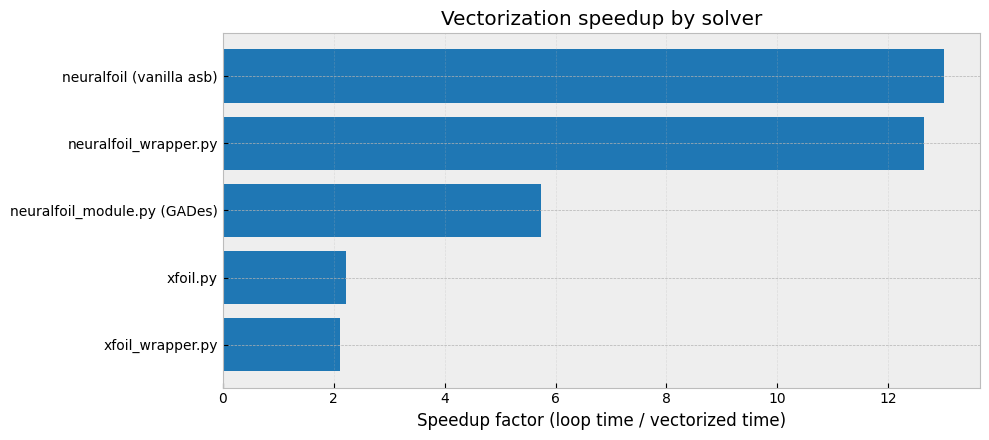

In [11]:
if 'vectorization_df' not in globals() or vectorization_df.empty:
    print("No vectorization results available.")
else:
    summary_cols = ["solver", "mode", "n_cases", "loop_seconds", "vector_seconds", "speedup_x"]
    display(vectorization_df[summary_cols].sort_values("speedup_x", ascending=False))

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ordered = vectorization_df.sort_values("speedup_x", ascending=True)
    ax.barh(ordered["solver"], ordered["speedup_x"], color="tab:blue")
    ax.set_xlabel("Speedup factor (loop time / vectorized time)")
    ax.set_title("Vectorization speedup by solver")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Notes

- The notebook is designed to continue running even if one or more solvers are unavailable; failures are captured in runtime tables.
- Error metrics are computed against a reference solver, preferring `xfoil.py` when available.
- All airfoils are instantiated with numfoil airfoil classes (`NACA4Airfoil` and `KulfanAirfoil`).
- Vectorization tests compare many scalar calls against one combined-grid call (or the closest supported equivalent).
- The multi-airfoil vectorization section now validates single-call full-grid coverage and Reynolds indexing behavior.